I am using nbev version 3.0.12 for this project. When I push to git it triggers a CI and a github pages workflow.  The pages workflow works but the Ci fails and I am struggling to see why.  The bottom of the log is:


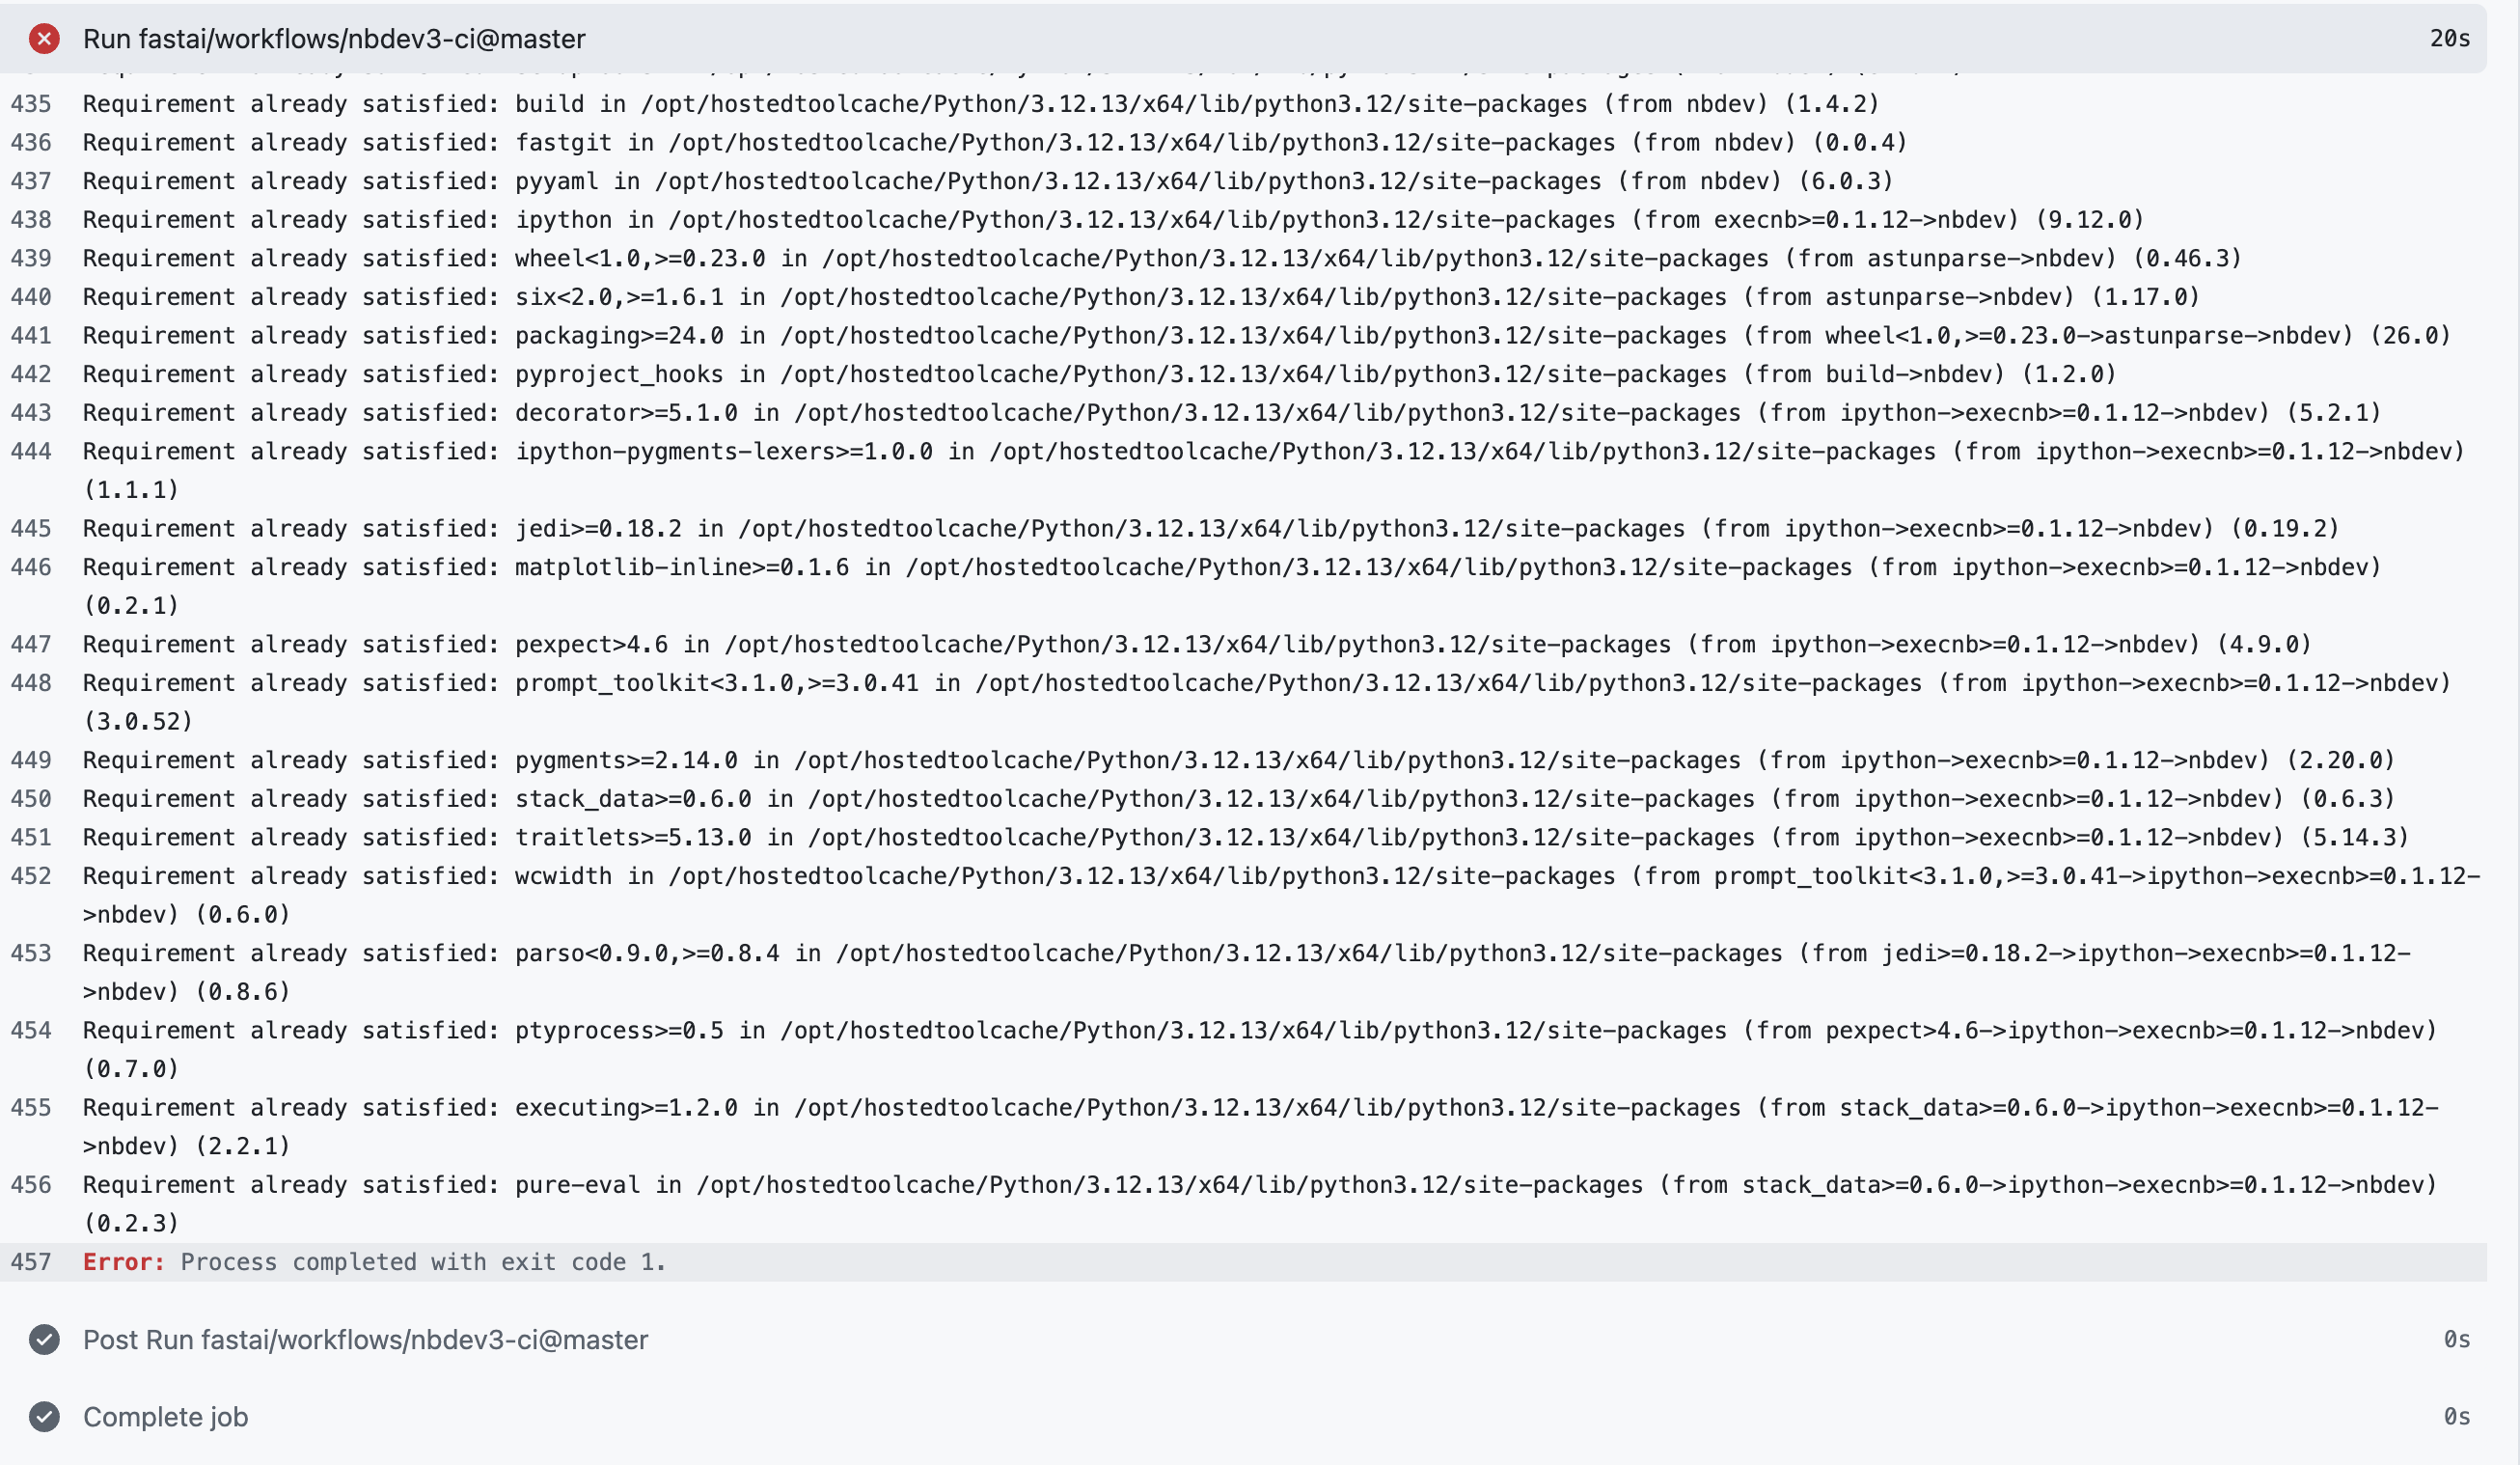

Can you see why this might be failing or suggest where I should look?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The log ends with **"Error: Process completed with exit code 1"** but the visible lines are all "Requirement already satisfied" — meaning the pip install step succeeded. The actual error is likely *above* what's shown in the screenshot.

Could you scroll up in the log to find the first line that says `Error` or shows a test failure/exception? That's most likely where the real problem is hiding.

<details class='token-usage-details'><summary>$0.1586</summary>

`total=28,064 | in=27,972 | out=92 | cached=0.0% | cache_new=27,278 | $0.1586`

</details>


I found: This error can also happen if you are using an older version of nbdev relative to what is in CI.  Please try to upgrade nbdev with the command Requirement already satisfied: nbdev in /opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages (3.0.12)

and also:
+ echo -e '!!! Detected unstripped out notebooks\n!!!Remember to run nbdev-clean'
!!! Detected unstripped out notebooks
!!!Remember to run nbdev-clean
++ pip install -U nbdev
+ echo -e 'This error can also happen if you are using an older version of nbdev relative to what is in CI.  Please try to upgrade nbdev with the command Requirement already satisfied: nbdev in /opt/hostedtoolcache/Python/3.12.13/x64/lib/python3.12/site-packages (3.0.12)

Though I have run nbdev-clean before I committed. I can't see any other reference to errors in the output

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

The error message is clear: **"Detected unstripped out notebooks"** — the CI is finding notebooks that haven't been cleaned, even though you ran `nbdev_clean` locally.

A common cause is that `nbdev_clean` wasn't run on *all* the notebooks that were committed, or a notebook was modified *after* running it.

A few things to check:

1. Did you run `nbdev_clean` and then make any further edits before committing?
2. Did you run it from the **root of your repo** (so it catches all notebooks)?

<details class='token-usage-details'><summary>$0.0209</summary>

`total=28,500 | in=28,368 | out=132 | cached=96.2% | cache_new=631 | $0.0209`

</details>
